# Deep Learning for Portfolio Optimization

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 17_portfolio_construction/11_dl_portfolio_allocation.py
> ```


This notebook implements end-to-end portfolio allocation using a neural network
that directly maximizes the portfolio Sharpe ratio - bypassing the predict-then-optimize
pipeline. The approach follows Zhang, Zohren & Roberts (2020).

**Learning Objectives**:
- Build an LSTM portfolio network that outputs asset weights via softmax
- Implement a differentiable Sharpe ratio loss function
- Train on rolling windows and evaluate out-of-sample
- Compare against equal-weight and inverse-volatility baselines
- Assess cost sensitivity of the learned allocator

**Book Reference**: Chapter 17, Section 17.8 (Deep learning for portfolio construction)

**Prerequisites**: `02_mean_variance_optimization`, `09_allocator_comparison`

## 1. Setup

In [1]:
"""Deep Learning for Portfolio Optimization - train a differentiable Sharpe-maximizing neural network allocator."""

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

In [2]:
# Production defaults - Papermill overrides for CI testing
MAX_SYMBOLS = 0  # 0 = all (uses full ETF universe below)
N_EPOCHS = 200
SEQ_LEN = 63  # ~3 months lookback
HIDDEN_DIM = 64
SEED = 42

One-way turnover counts half the absolute change for fully invested weights: a book that
sells one position entirely and buys another in its place has changed weights by two in
absolute terms and has traded once.

In [3]:
def one_way_turnover(delta):
    return 0.5 * np.abs(delta).sum(axis=-1)

### Determinism

Training a network twice on the same data gives the same weights only if every source of
randomness is pinned. `set_global_seeds` covers Python, NumPy and Torch; the two cuDNN
settings and the cuBLAS workspace variable below cover the GPU kernels, which otherwise
choose an algorithm by timing and so vary run to run.

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # required for det. cuBLAS
os.environ["PYTHONHASHSEED"] = str(SEED)

Device: cuda


## 2. Data: ETF Universe

This notebook uses a smaller DL-friendly ETF subset (29 assets after the coverage
filter is applied below) rather than the 36-ETF protocol of `09_allocator_comparison`.
The reduced cross-section keeps the LSTM parameter count manageable and the training
run tractable on a single GPU while still spanning equities, fixed income, sector
rotation, and alternatives.

In [5]:
US_EQUITY = ["SPY", "QQQ", "IWM", "VTV", "VUG", "MDY"]
INTERNATIONAL = ["EFA", "EEM", "VEA", "VWO"]
FIXED_INCOME = ["AGG", "TLT", "LQD", "HYG", "TIP", "SHY", "IEF"]
ALTERNATIVES = ["GLD", "SLV", "VNQ", "DBC"]
SECTORS = ["XLF", "XLE", "XLK", "XLV", "XLI", "XLU", "XLP", "XLY"]
UNIVERSE = [*US_EQUITY, *INTERNATIONAL, *FIXED_INCOME, *ALTERNATIVES, *SECTORS]

if MAX_SYMBOLS > 0:
    UNIVERSE = UNIVERSE[:MAX_SYMBOLS]

N_ASSETS = len(UNIVERSE)
print(f"Universe: {N_ASSETS} ETFs")

Universe: 29 ETFs


### Load the Price Panel

We keep Polars at the I/O boundary, then switch to pandas for the rolling
feature engineering and PyTorch tensor assembly used later in the notebook.

In [6]:
etf_data = load_etfs()
etf_filtered = etf_data.filter(pl.col("symbol").is_in(UNIVERSE))

prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)
prices = prices[[c for c in UNIVERSE if c in prices.columns]]

# Drop dates before most assets exist, then forward-fill small gaps
coverage_threshold = max(1, int(prices.shape[1] * 0.8))
prices = prices.dropna(thresh=coverage_threshold)
prices = prices.ffill()
prices = prices.dropna()
N_ASSETS = prices.shape[1]
UNIVERSE = list(prices.columns)

print(f"Price panel: {prices.shape[0]} dates × {prices.shape[1]} assets")
print(f"Date range: {prices.index[0]:%Y-%m-%d} to {prices.index[-1]:%Y-%m-%d}")

Price panel: 4639 dates × 29 assets
Date range: 2007-07-26 to 2025-12-31


**Interpretation**: The coverage filter keeps the network in a common investable
panel instead of letting late-listed ETFs create spurious weight shifts.

## 3. Feature Engineering

Simple features: multi-horizon log returns and rolling volatility.
The key insight from Zhang & Zohren is that the network can learn
allocation directly from raw return features - no alpha prediction needed.

In [7]:
returns = prices.pct_change().fillna(0.0)

# Multi-horizon returns (1d, 5d, 21d, 63d)
HORIZONS = [1, 5, 21, 63]
features_list = []
for h in HORIZONS:
    feat = prices / prices.shift(h) - 1.0
    feat = feat.fillna(0.0)
    features_list.append(feat.values)

# Rolling volatility (21d)
vol_21 = returns.rolling(21, min_periods=5).std().fillna(0.0)
features_list.append(vol_21.values)

# Stack: (T, N, F)
features = np.stack(features_list, axis=-1).astype(np.float32)
N_FEATURES = features.shape[-1]

print(
    f"Feature tensor: {features.shape} (T={features.shape[0]}, N={features.shape[1]}, F={features.shape[2]})"
)

Feature tensor: (4639, 29, 5) (T=4639, N=29, F=5)


## 4. Train/Validation/Test Split

Walk-forward: train on the first portion, validate to select best epoch,
test on the final unseen period.

In [8]:
dates = prices.index
n_dates = len(dates)

# 60% train, 20% val, 20% test
train_end = int(n_dates * 0.6)
val_end = int(n_dates * 0.8)

print(f"Train: {dates[0]:%Y-%m-%d} to {dates[train_end - 1]:%Y-%m-%d} ({train_end} days)")
print(
    f"Val:   {dates[train_end]:%Y-%m-%d} to {dates[val_end - 1]:%Y-%m-%d} ({val_end - train_end} days)"
)
print(
    f"Test decision dates: {dates[val_end]:%Y-%m-%d} to {dates[-2]:%Y-%m-%d} ({n_dates - val_end - 1} days)"
)
print(f"Last realized-return date: {dates[-1]:%Y-%m-%d} (not a decision origin)")

Train: 2007-07-26 to 2018-08-13 (2783 days)
Val:   2018-08-14 to 2022-04-20 (928 days)
Test decision dates: 2022-04-21 to 2025-12-30 (927 days)
Last realized-return date: 2025-12-31 (not a decision origin)


**Interpretation**: The split preserves a strict walk-forward protocol: the test
period remains untouched during model fitting and epoch selection.

## 5. Dataset and DataLoader

Sliding windows of length `SEQ_LEN`. Each window produces features and
forward returns for the loss computation.

In [9]:
fwd_returns = returns.shift(-1).fillna(0.0).values.astype(np.float32)


class PortfolioDataset(Dataset):
    """Sliding window dataset for portfolio optimization."""

    def __init__(self, features, fwd_returns, start_idx, end_idx, seq_len):
        self.features = features
        self.fwd_returns = fwd_returns
        self.seq_len = seq_len
        # Valid starting positions: need seq_len days + 1 for forward return
        self.indices = np.arange(
            max(start_idx, seq_len - 1),
            min(end_idx, len(features) - 1),
        )

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t = self.indices[idx]
        x = self.features[t - self.seq_len + 1 : t + 1]  # (L, N, F)
        r = self.fwd_returns[t - self.seq_len + 1 : t + 1]  # (L, N)
        return torch.from_numpy(x), torch.from_numpy(r)


train_ds = PortfolioDataset(features, fwd_returns, 0, train_end, SEQ_LEN)
val_ds = PortfolioDataset(features, fwd_returns, train_end, val_end, SEQ_LEN)
test_ds = PortfolioDataset(features, fwd_returns, val_end, n_dates, SEQ_LEN)

print(f"Train windows: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
assert train_ds.indices[-1] == train_end - 1
assert val_ds.indices[0] == train_end and val_ds.indices[-1] == val_end - 1
assert test_ds.indices[0] == val_end and test_ds.indices[-1] == n_dates - 2
assert all(test_ds.indices < n_dates - 1)

train_loader = DataLoader(train_ds, batch_size=len(train_ds), shuffle=False, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Train windows: 2721, Val: 928, Test: 927


## 6. LSTM Portfolio Network

The architecture is minimal: features pass through an LSTM, and a linear head
plus softmax produces long-only portfolio weights. The softmax constraint
ensures weights sum to 1 and are non-negative.

In [10]:
class LSTMPortfolioNet(nn.Module):
    """LSTM that outputs long-only portfolio weights via softmax."""

    def __init__(self, n_features, n_assets, hidden_dim):
        super().__init__()
        self.n_assets = n_assets
        self.lstm = nn.LSTM(
            input_size=n_features * n_assets,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Linear(hidden_dim, n_assets)

    def forward(self, x):
        # x: (B, T, N, F) -> flatten asset×feature dimension
        b, t, n, f = x.shape
        x_flat = x.reshape(b, t, n * f)
        h, _ = self.lstm(x_flat)
        logits = self.head(h)  # (B, T, N)
        weights = torch.softmax(logits, dim=-1)
        return weights


model = LSTMPortfolioNet(N_FEATURES, N_ASSETS, HIDDEN_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 55,901


## 7. Differentiable Sharpe Ratio Loss

The core innovation: instead of predicting returns and then optimizing,
we directly maximize the portfolio Sharpe ratio through backpropagation.

$$\mathcal{L} = -\frac{\sqrt{252} \cdot \bar{r}_p}{\sqrt{\text{Var}(r_p) + \epsilon}}$$

where $r_p = \sum_i w_i \cdot r_i$ is the portfolio return at each step.

In [11]:
def differentiable_sharpe_loss(weights, fwd_returns, annualization=252.0, eps=1e-8):
    """Negative Sharpe ratio of the portfolio return series.

    Parameters
    ----------
    weights : (B, T, N) portfolio weights (sum to 1 per timestep)
    fwd_returns : (B, T, N) forward asset returns

    Returns
    -------
    Scalar loss (negative Sharpe).
    """
    # Portfolio returns: weighted sum across assets
    port_returns = (weights[:, -1, :] * fwd_returns[:, -1, :]).sum(dim=-1)  # one per decision date

    # Pool one final decision return per window across the batch
    r = port_returns.reshape(-1)
    mu = r.mean()
    var = r.var(unbiased=False)
    sharpe = (annualization**0.5) * mu / torch.sqrt(var + eps)
    return -sharpe

## 8. Training Loop

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

### Sharpe Utility

In [13]:
def annualized_sharpe(returns_tensor, annualization=252.0):
    """Annualized Sharpe for a 1D return tensor."""
    return float((annualization**0.5) * returns_tensor.mean() / (returns_tensor.std() + 1e-8))

### One-Epoch Update

In [14]:
def train_one_epoch(train_loader, model, optimizer):
    """Run one training epoch and return annualized Sharpe."""
    model.train()
    epoch_returns = []
    for x_batch, r_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        r_batch = r_batch.to(DEVICE)

        optimizer.zero_grad()
        weights = model(x_batch)
        loss = differentiable_sharpe_loss(weights, r_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            port_r = (weights[:, -1, :] * r_batch[:, -1, :]).sum(dim=-1)
            epoch_returns.append(port_r.cpu())

    all_returns = torch.cat(epoch_returns)
    return annualized_sharpe(all_returns)

### Validation Pass

In [15]:
def evaluate_sharpe(loader, model):
    """Evaluate annualized Sharpe on validation or test windows."""
    model.eval()
    eval_returns = []
    with torch.no_grad():
        for x_batch, r_batch in loader:
            x_batch = x_batch.to(DEVICE)
            r_batch = r_batch.to(DEVICE)
            weights = model(x_batch)
            port_r = (weights[:, -1, :] * r_batch[:, -1, :]).sum(dim=-1)
            eval_returns.append(port_r.cpu())
    all_returns = torch.cat(eval_returns)
    return annualized_sharpe(all_returns)

In [16]:
train_sharpes = []
val_sharpes = []
best_val_sharpe = -np.inf
best_state = None

print(f"Training for {N_EPOCHS} epochs...")
for epoch in range(1, N_EPOCHS + 1):
    train_sr = train_one_epoch(train_loader, model, optimizer)
    train_sharpes.append(train_sr)
    scheduler.step()

    val_sr = evaluate_sharpe(val_loader, model)
    val_sharpes.append(val_sr)

    if val_sr > best_val_sharpe:
        best_val_sharpe = val_sr
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train SR: {train_sr:+.3f} | Val SR: {val_sr:+.3f}")

if best_state is None:
    raise RuntimeError("Training produced no model state to evaluate.")

print(f"Best validation Sharpe: {best_val_sharpe:.3f}")

Training for 200 epochs...


Epoch   1 | Train SR: +0.517 | Val SR: +0.757


Epoch  25 | Train SR: +0.784 | Val SR: +0.950


Epoch  50 | Train SR: +1.457 | Val SR: +1.090


Epoch  75 | Train SR: +1.656 | Val SR: +1.074


Epoch 100 | Train SR: +1.735 | Val SR: +1.005


Epoch 125 | Train SR: +2.033 | Val SR: +1.042


Epoch 150 | Train SR: +2.212 | Val SR: +1.035


Epoch 175 | Train SR: +2.290 | Val SR: +1.007


Epoch 200 | Train SR: +2.304 | Val SR: +1.002
Best validation Sharpe: 1.090


## 9. Training Diagnostics

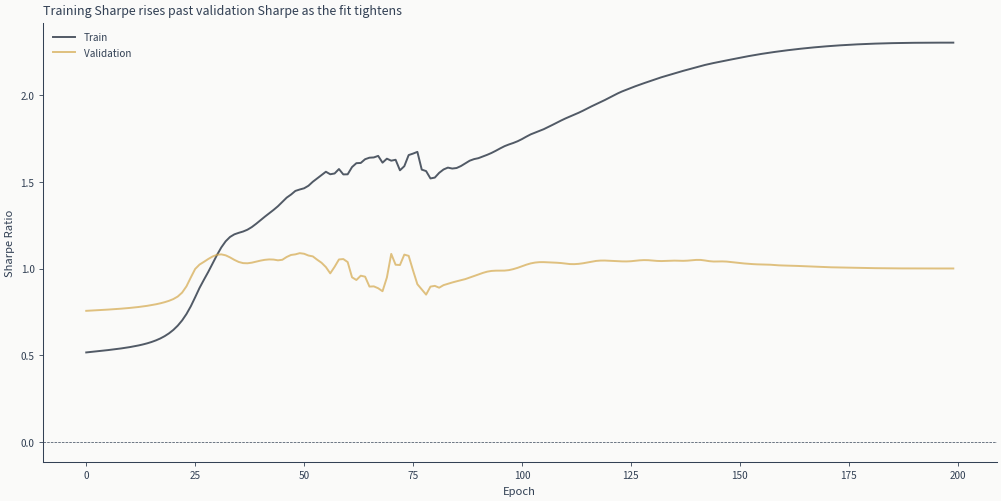

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sharpes, label="Train", color=COLORS["blue"], alpha=0.7)
ax.plot(val_sharpes, label="Validation", color=COLORS["amber"], alpha=0.7)
ax.legend()
ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Sharpe Ratio")
ax.set_title("Training Sharpe rises past validation Sharpe as the fit tightens")
show_with_alt(
    fig,
    "Training and validation annualized Sharpe against epoch, the training curve rising steadily and the validation curve flatter and noisier, with a reference line at zero.",
)

The two curves are measured differently, and the difference is worth knowing before reading a
gap between them. `train_one_epoch` runs the whole training window as one batch, records the
portfolio returns from that forward pass, and then takes the optimizer step; the training
Sharpe plotted for an epoch is therefore the weights *before* that epoch's update, scored on
the training window. `evaluate_sharpe` runs after the step, on the validation window, with the
weights frozen. Two things separate the curves - the window and one update - so a gap between
them is not a clean measure of generalization on its own.

What the pair is for is the shape over epochs. A training curve that keeps rising while the
validation curve flattens or turns down is the standard signal that further steps are fitting
the training window, and the checkpoint kept is the one at the validation peak rather than the
one at the last epoch.

## 10. Out-of-Sample Evaluation

Load best model and compute test-period portfolio returns.
Compare with equal-weight and inverse-volatility baselines.

In [18]:
model.load_state_dict(best_state)
model.eval()

LSTMPortfolioNet(
  (lstm): LSTM(145, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=29, bias=True)
)

### Daily Return Extraction Helper

We evaluate each method on the same test windows by extracting the final step return from
each sliding sequence.

In [19]:
def compute_portfolio_returns(loader, model_fn):
    """Compute daily portfolio returns from a loader."""
    all_returns = []
    with torch.no_grad():
        for x_batch, r_batch in loader:
            x_batch = x_batch.to(DEVICE)
            r_batch = r_batch.to(DEVICE)
            w = model_fn(x_batch)
            port_r = (w * r_batch).sum(dim=-1)
            # Take last timestep per window (non-overlapping returns)
            all_returns.append(port_r[:, -1].cpu().numpy())
    return np.concatenate(all_returns)


# LSTM portfolio
lstm_returns = compute_portfolio_returns(test_loader, model)

### Equal-Weight Baseline

In [20]:
def equal_weight_fn(x):
    b, t, n, f = x.shape
    return torch.ones(b, t, n, device=x.device) / n


ew_returns = compute_portfolio_returns(test_loader, equal_weight_fn)

### Inverse-Volatility Baseline

In [21]:
def inv_vol_fn(x):
    # Use rolling vol from the last feature channel
    vol = x[:, :, :, -1].clamp(min=1e-6)  # (B, T, N)
    inv_vol = 1.0 / vol
    return inv_vol / inv_vol.sum(dim=-1, keepdim=True)


iv_returns = compute_portfolio_returns(test_loader, inv_vol_fn)

### Performance Comparison

In [22]:
def compute_metrics(returns, name, ann_factor=252.0):
    """Compute portfolio performance metrics."""
    r = pd.Series(returns)
    mu = r.mean() * ann_factor
    vol = r.std() * np.sqrt(ann_factor)
    sharpe = mu / (vol + 1e-8)
    cum = (1 + r).cumprod()
    max_dd = float((cum / cum.cummax() - 1).min())
    return {
        "Method": name,
        "Ann. Return": f"{mu:.1%}",
        "Ann. Vol": f"{vol:.1%}",
        "Sharpe": f"{sharpe:.2f}",
        "Max DD": f"{max_dd:.1%}",
    }


results = pd.DataFrame(
    [
        compute_metrics(lstm_returns, "LSTM Portfolio"),
        compute_metrics(ew_returns, "Equal Weight"),
        compute_metrics(iv_returns, "Inverse Volatility"),
    ]
)
results

,Method,Ann. Return,Ann. Vol,Sharpe,Max DD
0,LSTM Portfolio,4.4%,7.3%,0.61,-11.0%
1,Equal Weight,10.0%,12.0%,0.84,-13.4%
2,Inverse Volatility,7.0%,8.1%,0.86,-10.4%


Read the four columns together rather than ranking on the Sharpe column. The loss the network
minimized is the negative Sharpe ratio of its own training window, so the training objective
and the evaluation metric are the same quantity measured on different dates - which makes the
gap between them a statement about generalization and nothing else.

The comparison that matters is against the two baselines, because of how little each has to
estimate. Equal weight estimates nothing at all. Inverse volatility estimates one number per
asset, a rolling 21-session standard deviation, and no expected return and no correlation - so
it is exposed to sampling error, but only in the input that is easiest to measure. A learned
allocator estimates a whole policy from the same history, and it has to beat both of them to
have earned that. The table says whether it did on these dates.

### Equity Curves

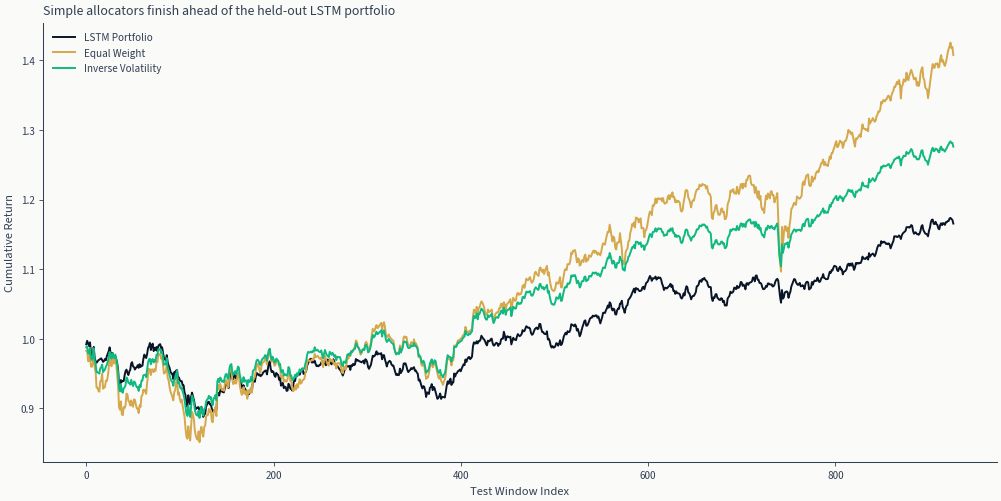

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
for returns_arr, label, color in [
    (lstm_returns, "LSTM Portfolio", COLORS["blue"]),
    (ew_returns, "Equal Weight", COLORS["amber"]),
    (iv_returns, "Inverse Volatility", COLORS["positive"]),
]:
    cum = np.cumprod(1 + returns_arr)
    ax.plot(cum, label=label, color=color)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Cumulative Return")
ax.set_title("Simple allocators finish ahead of the held-out LSTM portfolio")
ax.legend()
show_with_alt(
    fig,
    "Three cumulative return paths over the test windows for the LSTM portfolio, equal weight and inverse volatility.",
)

**Trading implication**: If the LSTM curve only tracks heuristic baselines, a simpler allocator
is preferable due to lower implementation and monitoring risk.

## 11. Weight Analysis

Examine the learned allocation: how concentrated are the positions,
and which assets dominate?

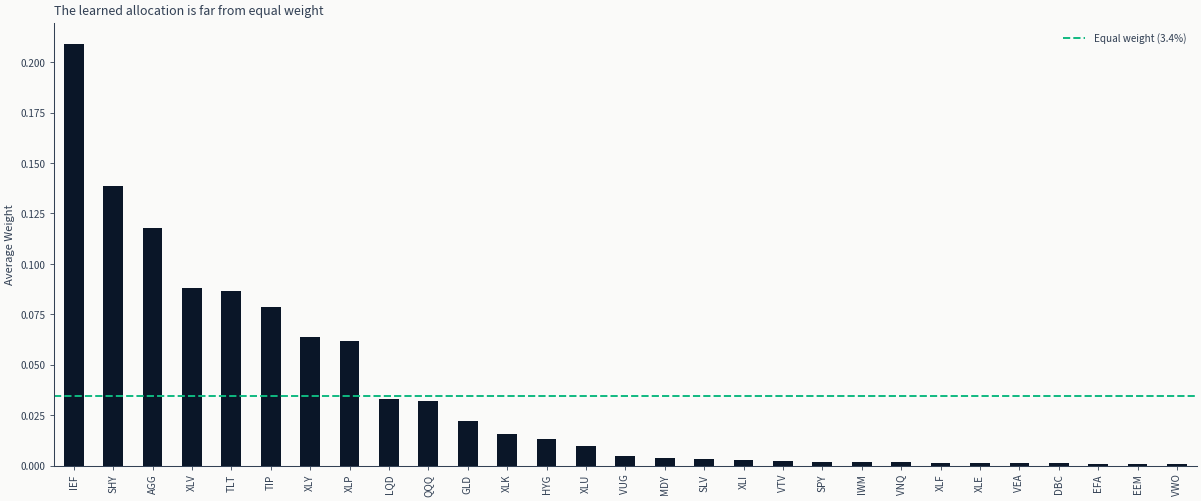

In [24]:
# Collect weights on test set
all_weights = []
model.eval()
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        w = model(x_batch)
        all_weights.append(w[:, -1, :].cpu().numpy())

test_weights = np.concatenate(all_weights, axis=0)

# Average allocation
avg_weights = pd.Series(test_weights.mean(axis=0), index=UNIVERSE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
avg_weights.plot(kind="bar", ax=ax, color=COLORS["blue"])
ax.set_ylabel("Average Weight")
ax.set_title("The learned allocation is far from equal weight")
ax.axhline(
    1.0 / N_ASSETS,
    color=COLORS["positive"],
    linestyle="--",
    label=f"Equal weight ({1 / N_ASSETS:.1%})",
)
ax.legend()
show_with_alt(
    fig,
    "Bars of the LSTM's average test-period weight per ETF, sorted from largest to smallest, with a dashed line at the equal-weight level.",
)

**Finding**: Persistent concentration in a small subset of ETFs indicates the model is learning
a structural allocation bias rather than purely time-varying tactical tilts.

### Weight Concentration Over Time

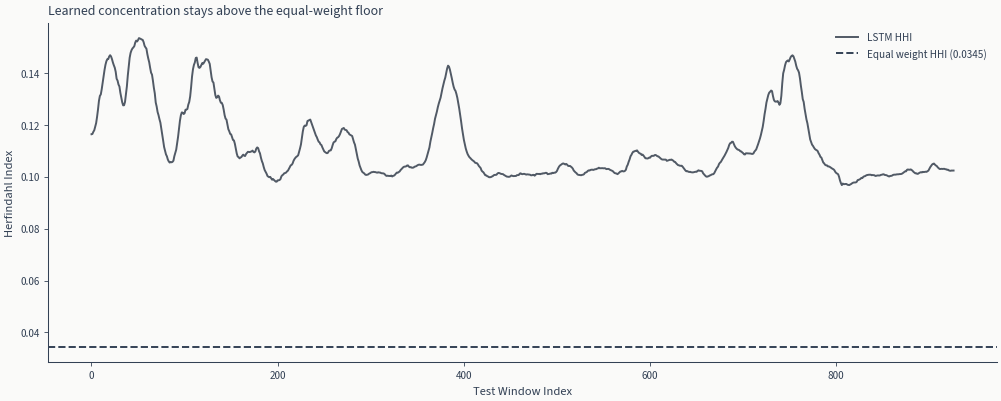

In [25]:
# Herfindahl index (concentration measure)
hhi = (test_weights**2).sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hhi, label="LSTM HHI", color=COLORS["blue"], alpha=0.7)
ax.axhline(
    1.0 / N_ASSETS,
    color=COLORS["neutral"],
    linestyle="--",
    label=f"Equal weight HHI ({1 / N_ASSETS:.4f})",
)
ax.set_xlabel("Test Window Index")
ax.set_ylabel("Herfindahl Index")
ax.set_title("Learned concentration stays above the equal-weight floor")
ax.legend()
show_with_alt(
    fig,
    "The Herfindahl index of the LSTM's weights against test window index, with a dashed line at the equal-weight index below it throughout.",
)

**Trading implication**: Higher concentration (HHI above equal-weight baseline) raises
idiosyncratic drawdown risk and should be paired with exposure constraints in production.

## 12. Realized Turnover (Sanity Check)

The training objective is a pure Sharpe loss with no turnover penalty (see
Takeaway 3), so realized turnover is an emergent property the loss does not
control. A full cost-grid sensitivity is deferred to Chapter 18; this notebook
reports realized turnover only as a sanity check on the magnitude of trading
the model implies.

In [26]:
# Mean per-rebalance Σ|Δw| across consecutive test-period weight vectors
turnover = np.abs(np.diff(test_weights, axis=0)).sum(axis=1)
avg_turnover = float(one_way_turnover(np.diff(test_weights, axis=0)).mean())
print(f"Realized one-way turnover (0.5 × mean Σ|Δw|): {avg_turnover:.4f}")
print(f"Realized one-way turnover (bps-equivalent): {avg_turnover * 10_000:.1f} bps")

Realized one-way turnover (0.5 × mean Σ|Δw|): 0.0037
Realized one-way turnover (bps-equivalent): 37.1 bps


**Interpretation**: Turnover is the bridge from apparent model edge to live
deployability. The number above is reported in raw weight-change units and as a
bps-equivalent one-way trade size; Chapter 18 attaches an explicit cost model and
compares the deployable Sharpe of this allocator against the simpler baselines.

### What this run produced

Three rows, one test window, three allocators over the same dates and the same funds. The LSTM
row is the one the network produced; the other two need no fitting at all and are what its
added machinery has to beat.

Two numbers below the table qualify it. The concentration series says how far from equal weight
the network chose to sit, which is what its return and volatility are bought with, and the
realized turnover says how much trading the weights imply. Neither the training loss nor this
table charges for that trading: Chapter 18 does, and until it is charged the Sharpe column is
a paper figure.

## Key Takeaways

1. **End-to-end optimization removes a step, not the estimation problem.** The network never
   forecasts a return, so there is no prediction to be wrong; what it estimates instead is the
   allocation directly, from the same noisy history, and the comparison against equal weight and
   inverse volatility is what says whether that trade paid on this universe.
2. **The loss is the contribution, not the architecture.** An LSTM with one layer and a linear
   head is the smallest network that can read a sequence, and it is deliberately small: what
   makes the method work is that the Sharpe ratio is differentiable in the weights, so
   backpropagation can optimize it directly.
3. **Realized turnover is computed from half the absolute weight change**: cost
   stress lives in Ch18, but the LSTM trained without an explicit cost-aware
   loss can produce substantial turnover; comparable baselines are not claimed here.
4. **Interpretability tradeoff**: Unlike predict-then-optimize, you cannot
   separately diagnose signal failure vs allocation failure.

**Next**: `12_vlstm_portfolio` introduces a TFT-style variable-selection block
in front of the LSTM encoder; `13_deepm_regime_robust` then adds the SoftMin
regime-robust loss and macro graph prior on top of that pipeline.

**Book**: Section 17.8 discusses the two-stage against end-to-end trade-off.